# 우송대학교 컴퓨터정보보안전공 202110716 백지원

## **더미변수회귀분석 예제**

### 데이터 준비

- 이완기 혈압(DBP, 종속변수)에 따른 수축기 혈압(SBP, 독립변수)의 회귀분석
    -> 측정시간에 따라 혈압이 달라짐
        -> 0: 기상 직후, 1: 오전 10시, 2: 오후 4시, 3: 취침 전

-  데이터를 가상으로 생성하여 회귀분석을 수행

In [1]:
# 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 생성
n = 10
np.random.seed(42)

# 이완기 혈압(DBP), 평균 90mmHg, 표준편차 10mmHg
df = pd.DataFrame({
    'DBP': np.random.normal(90, 10, n*4),
    'time': np.repeat([0, 1, 2, 3], n)
})

# 수축기 혈압(SBP) = 15 + 1.2*이완기 혈압(DBP) + 랜덤 노이즈
sbp_0 = 10.0 + 1.2*df['DBP'][:0+n] + np.random.randint(-15, 15, n)
sbp_1 = 15.0 + 1.3*df['DBP'][n:2*n] + np.random.randint(-15, 15, n)
sbp_2 = 20.0 + 1.3*df['DBP'][2*n:3*n] + np.random.randint(-15, 15, n)
sbp_3 = 5.0 + 1.2*df['DBP'][3*n:4*n] + np.random.randint(-15, 15, n)
df['SBP'] = pd.concat([sbp_0, sbp_1, sbp_2, sbp_3], axis=0)

# 데이터 확인
df.head()

,DBP,time,SBP
0,94.967142,0,125.960570
1,88.617357,0,126.340828
2,96.476885,0,121.772262
3,105.230299,0,122.276358
4,87.658466,0,109.190160


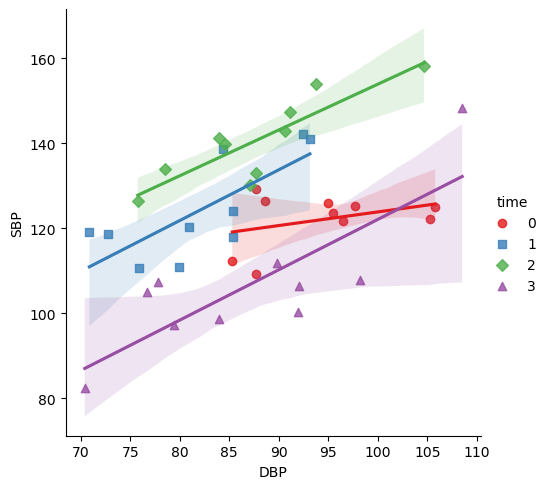

In [2]:
# 데이터프레임 산점도 그리기
sns.lmplot(
    data=df,
    x='DBP',
    y='SBP',
    hue='time',
    markers=['o', 's', 'D', '^'],
    palette='Set1',
);


### 단순선형회귀분석 적용

In [3]:
import statsmodels.formula.api as smf

# 회귀모형 생성
formula = 'SBP ~ DBP'

# OLS 클래스로 선형회귀모형의 객체를 생성하고 fit 메서드로 모형 추정
model = smf.ols(formula, data=df).fit()

# summary 메서드로 결과 출력
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    SBP   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     9.669
Date:                Tue, 08 Jul 2025   Prob (F-statistic):            0.00354
Time:                        23:40:06   Log-Likelihood:                -164.53
No. Observations:                  40   AIC:                             333.1
Df Residuals:                      38   BIC:                             336.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     53.7646     22.530      2.386      0.0

- 산점도와 회귀선 그리기

Text(0.5, 1.0, 'SBP vs. DBP')

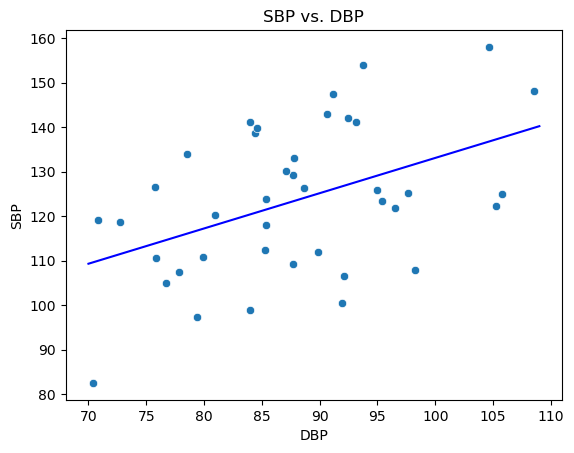

In [4]:
# 산점도 그리기
sns.scatterplot(
    data=df,    # 데이터프레임
    x='DBP',    # x축 변수
    y='SBP'     # y축 변수
)

# 회귀선을 그리기 위한 데이터프레임 생성
# DBP의 범위 설정
x = range(70, 110)

# 예측값 계산을 위한 데이터프레임 생성
y = pd.DataFrame({'DBP': x})

# 회귀선 그리기
plt.plot(x, model.predict(y), color='blue')

# 그래프 제목 및 축 레이블 설정
plt.xlabel('DBP')
plt.ylabel('SBP')
plt.title('SBP vs. DBP')


### 더미 변수를 적용한 회귀분석

- `time` 변수를 더미변수로 변환 `C(time)` 하여 회귀분석을 수행
  - 범주형 변수가 여러 개인 경우, **축소랭크(reduced-rank)** 방식을 사용
  - 축소랭크(reduced-rank) 방식에서는 특정한 하나의 범주값을 **기준값(reference, baseline)** 으로 하고, 
    기준값에 각 더미변수의 계수를 상수로 회귀모형에 추가
    - 여기서는 `time = 0`이 기준값으로 설정됨


In [5]:
# 회귀모형 생성
formula = 'SBP ~ DBP + C(time)'

# OLS 클래스로 선형회귀모형의 객체를 생성하고 fit 메서드로 모형 추정
model = smf.ols(formula, data=df).fit()

# summary 메서드로 결과 출력
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    SBP   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     33.26
Date:                Tue, 08 Jul 2025   Prob (F-statistic):           1.77e-11
Time:                        23:43:43   Log-Likelihood:                -137.68
No. Observations:                  40   AIC:                             285.4
Df Residuals:                      35   BIC:                             293.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       26.2035     14.761      1.775   

- 산점도와 회귀도 시각화

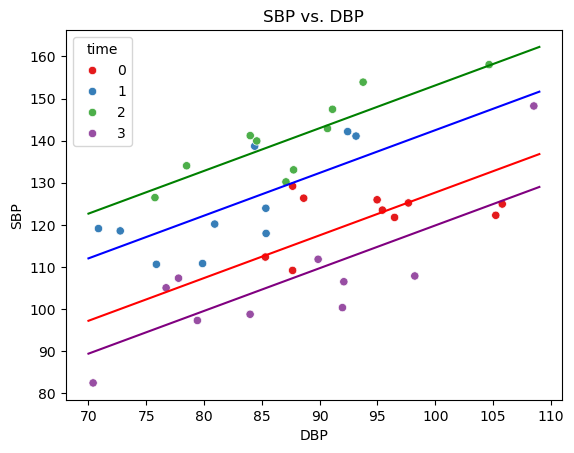

In [6]:
sns.scatterplot(
    data=df,             # 데이터프레임
    x='DBP',             # x축 변수
    y='SBP',             # y축 변수
    hue='time',          # 범주형 변수
    markers=['o', 's', 'D', '^'],  # 마커 모양
    palette='Set1'       # 색상 팔레트
)

# 회귀선을 그리기 위한 데이터프레임 생성
# DBP의 범위 설정
x = range(70, 110)

# time=0, 1, 2, 3에 대한 예측값을 계산하기 위한 데이터프레임 생성
y_0 = pd.DataFrame({'DBP': x, 'time': 0})
y_1 = pd.DataFrame({'DBP': x, 'time': 1})
y_2 = pd.DataFrame({'DBP': x, 'time': 2})
y_3 = pd.DataFrame({'DBP': x, 'time': 3})

# 회귀선 그리기
plt.plot(x, model.predict(y_0), label='time=0', color='red')
plt.plot(x, model.predict(y_1), label='time=1', color='blue')
plt.plot(x, model.predict(y_2), label='time=2', color='green')
plt.plot(x, model.predict(y_3), label='time=3', color='purple')

# 그래프 제목 및 축 레이블 설정
plt.xlabel('DBP')
plt.ylabel('SBP')
plt.title('SBP vs. DBP')
plt.show()


## 응용 코드

### 1. 이완기 혈압(DBP)과 수축기 혈압(SBP)의 관계 분석

                            OLS Regression Results                            
Dep. Variable:                    SBP   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.905e+29
Date:                Tue, 08 Jul 2025   Prob (F-statistic):           1.20e-72
Time:                        23:51:21   Log-Likelihood:                 204.28
No. Observations:                   7   AIC:                            -404.6
Df Residuals:                       5   BIC:                            -404.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     40.0000   1.96e-13   2.04e+14      0.0

c:\Users\eksql\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


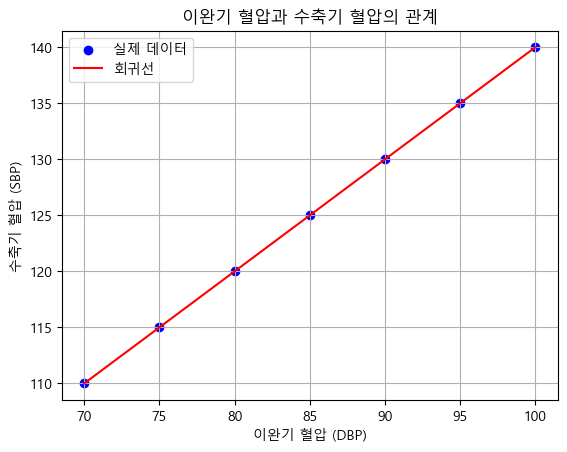

In [8]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 준비
data = {
    'DBP': [70, 75, 80, 85, 90, 95, 100],   # 이완기 혈압
    'SBP': [110, 115, 120, 125, 130, 135, 140]  # 수축기 혈압
}
df = pd.DataFrame(data)

# 회귀모형 정의 및 추정
formula = 'SBP ~ DBP'
model = smf.ols(formula, data=df).fit()

# 결과 출력
print(model.summary())

# 시각화 (산점도 + 회귀선)
plt.scatter(df['DBP'], df['SBP'], color='blue', label='실제 데이터')
plt.plot(df['DBP'], model.predict(df), color='red', label='회귀선')

# 그래프 꾸미기
plt.xlabel('이완기 혈압 (DBP)')
plt.ylabel('수축기 혈압 (SBP)')
plt.title('이완기 혈압과 수축기 혈압의 관계')
plt.legend()
plt.grid(True)
plt.show()

### 2. 운동 여부에 따른 혈압 변화 회귀선 비교

- DBP(이완기 혈압) → SBP(수축기 혈압)을 예측
- 각 그룹별로 회귀선을 그려서 운동이 혈압 관계에 어떤 영향을 주는지 확인

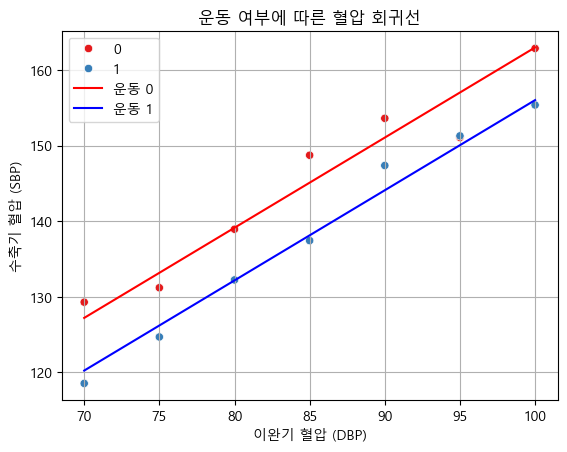

In [9]:
# 샘플 데이터 생성
np.random.seed(0)
df = pd.DataFrame({
    'DBP': np.tile(np.arange(70, 101, 5), 2),
    'exercise': [0]*7 + [1]*7
})
df['SBP'] = 40 + 1.2*df['DBP'] + df['exercise']*(-5) + np.random.normal(0, 3, len(df))

# 회귀모형 적합
model = smf.ols('SBP ~ DBP + C(exercise)', data=df).fit()

# 시각화
sns.scatterplot(data=df, x='DBP', y='SBP', hue='exercise', palette='Set1')

x = np.linspace(70, 100, 100)
for i, color in zip([0, 1], ['red', 'blue']):
    temp = pd.DataFrame({'DBP': x, 'exercise': i})
    plt.plot(x, model.predict(temp), color=color, label=f'운동 {i}')

plt.xlabel('이완기 혈압 (DBP)')
plt.ylabel('수축기 혈압 (SBP)')
plt.title('운동 여부에 따른 혈압 회귀선')
plt.legend()
plt.grid(True)
plt.show()